# Labeling

<a target="_blank" href="https://colab.research.google.com/github/pleyad/Summer-School-2026/blob/main/notebooks/XX_Labeling.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Housekeeping (no interaction required)

In [14]:
%pip install openrouter
# Is dotenv installed?

/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
from dataclasses import dataclass
import json
import os
import random
import textwrap
import time
from pathlib import Path

import pandas as pd
from tqdm.notebook import tqdm
from openrouter import OpenRouter


tqdm.pandas()

In [16]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')
MODEL_NAME = "openai/gpt-5.4-mini"

In [17]:
def confirm(question: str = "Do you want to execute this cell?"):
    while True:
        response = input(f"{question} (y/n): ").lower()
        if response in ["y", "yes"]:
            return True
        elif response in ["n", "no"]:
            return False
        else:
            print("Please enter 'y' or 'n'.")

## Setup (Interaction required)

### Load the data

In [18]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to continue with your own query
CORPUS_NAME = "armenpflege"
LOAD_OWN_DATA = True
YOUR_NAME = "niclas"
SEPARATOR = ";"  # Separator for the CSV file, e.g., ";" for semicolon, "," for comma
### ⬆️⬆️⬆️

In [19]:
if IN_COLAB and LOAD_OWN_DATA: # and confirm("Do you want to mount your Google Drive?"):
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

#### <img src="https://cdn.simpleicons.org/googledrive" alt="💾" width=16> Load your own data from Google Drive

#### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [20]:
if LOAD_OWN_DATA:
    # RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.parquet" # Use data from filtering module
    # raw_df = pd.read_parquet(RAWDATA_PATH)

    # SENTENCES_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.sentences.parquet" # Use data from filtering module
    # sentences_df = pd.read_parquet(SENTENCES_PATH)

    # raw_df = raw_df.join(sentences_df, on="id")

    LABELS_PATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.{YOUR_NAME}.csv" # Use data from filtering module
    labels_df = pd.read_csv(LABELS_PATH, index_col="id", sep=SEPARATOR)

In [21]:
if not LOAD_OWN_DATA:
    # RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.csv" 
    # raw_df = pd.read_csv(RAWDATA_ORIGIN_URL, index_col="id")

    # RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.parquet"
    # print(f"Loading raw data ...", end="\r")
    # raw_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

    # SENTENCES_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.filtered.sentences.parquet"
    # print(f"Loading sentences data ...", end="\r")
    # sentences_df = pd.read_parquet(SENTENCES_URL)

    LABELS_PATH = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armenpflege.filtered.pp.label.niclas.csv"
    labels_df = pd.read_csv(LABELS_PATH, index_col="id", sep=SEPARATOR)

    # raw_df = raw_df.join(sentences_df)

In [22]:
# ⚙️ Developer 

# def rename_labels(label):
#     mapping = {
#             "Protokollarischer Bericht": "Protokollarischer Bericht", #"Bericht", #"Protokollarischer Bericht",
#             "Meinungsartikel": "Meinungsartikel",
#             "Einzelfall": "Einzelfall",
#             "Budgetbericht": "Budgetbericht",#"Bericht", #"Budgetbericht",
#             "Budget": "Budgetbericht", #"Bericht", #"Budgetbericht",
#             "Sachdarstellung": "Sachdarstellung"
#         }
#     return mapping.get(label, label)

# labels_df["label"] = labels_df["label"].apply(rename_labels)

### Enable LLM interaction

In [23]:
from openrouter import OpenRouter
import os
import dotenv
dotenv.load_dotenv()

with OpenRouter(
  # api_key=API_KEY,
  api_key=os.getenv("OPENROUTER_API_KEY"),
) as client:
  response = client.chat.send(
    model=MODEL_NAME,
    messages=[
      {
        "role": "user",
        "content": "What is the meaning of life?"
      }
    ],
    max_tokens=100
  )

print(response.choices[0].message.content)

There isn’t one universally agreed answer, but a few common ways people frame it are:

- **Create meaning yourself** through love, work, learning, and contribution.
- **Reduce suffering and increase well-being** for yourself and others.
- **Experience and appreciate existence**: relationships, beauty, curiosity, growth.
- **Serve something larger than yourself**: family, community, values, faith, or a cause.

If you want a short, practical answer: **the meaning


## Introduction to Prompting

### Hands-on:
Now try the following things:

1.   Change the user prompt and re-run the request.
2.   Change the system prompt to something completely random and re-run the request.

#### Temperature and top-p
Let's go through each of these arguments one-by-one. Below you will see API calling code for the LLM with a slightly more complex prompt. Try out requests to this LLM where you:


1.   Vary the temperature parameter.
2. Vary the top-p parameter.

Your task is try to get the funniest and weirdest response possible from the model.

In order to prevent too excessive an output (and to protect our budget!) we'll limit the output to a maximum of 50 tokens using the `max_tokens` argument; please do not change this.

In [24]:
# ⬇️⬇️⬇️ Adjust the system and user prompts here to see how it affects the output
longer_system_prompt = (
    "You are a political text classifier. Given a social media post, return a JSON object "
    "with exactly four fields: "
    "\"topic\" (a short label for the main topic, e.g. 'economy', 'healthcare', 'immigration'), "
    "\"sentiment\" (one of: 'positive', 'negative', 'neutral'), and "
    "\"is_political\" (true or false). "
    "Return only the JSON object, nothing else."
)
longer_user_prompt = (
    "Post: 'Can't believe they're cutting the healthcare budget again while giving tax breaks "
    "to billionaires. This government doesn't care about ordinary people.'"
)
# ⬆️⬆️⬆️

In [25]:
with OpenRouter(
  api_key=os.getenv("OPENROUTER_API_KEY"),
) as client:
    response = client.chat.send(
        model=MODEL_NAME,
        messages=[
        {"role": "system", "content": longer_system_prompt},
        {"role": "user", "content": longer_user_prompt}
        ],
        max_tokens=50,

        # ⬇️⬇️⬇️ Adjust these parameters to see how it affects the output
        temperature=1, # 0-1
        top_p=0.1 # 0-1
        # ⬆️⬆️⬆️
    )

output_text = response.choices[0].message.content  # take the output and extract the text response only

# parse and pretty-print the JSON output
parsed = json.loads(output_text)
print(json.dumps(parsed, indent=2))

{
  "topic": "healthcare",
  "sentiment": "negative",
  "is_political": true
}


## Inspect your gold standard

For our 'Armenpflege' example, we inductively arrived at three classes for the articles.

![categories_better](../assets/armenpflege_kategoriensystem.excalidraw.png)

*Meinungsartikel*: An article where someone (the author or a cited speaker) explicitely mentions how the 'Armenpflege' or a related topic ought to be or where an explicit valorisation is made.

*Unspezifischer Bericht*: An article containing a recollection of events or a description of facts without any explicit markers of subjectivity. Does not include articles that fall under "Einzelfalldarstellung".

*Einzelfalldarstellung*: An article that describes the circumstances of a concrete person or group that interacted with the 'Armenpflege', mainly as recipients. Articles around singular politicians or institutional actors do not fall under 'Einzelfalldarstellung'.


In [26]:
labels_df[labels_df["label"].notna()].value_counts(subset=["label"])

label                 
Unspezifischer Bericht    54
Meinungsartikel           18
Einzelfalldarstellung      8
Name: count, dtype: int64

## Assess labels and classification schemes by comparing the results of two human coders

The code in this chapter needs the labels of two different people.
We have prepared two labellers


In [27]:
NICLAS_PATH = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armenpflege.filtered.pp.label.niclas.csv"
niclas_df = pd.read_csv(NICLAS_PATH, index_col="id", sep=SEPARATOR)
niclas_df = niclas_df[niclas_df["label"].notna()]

# ELIAS_PATH = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armenpflege.filtered.pp.label.elias.csv"
ELIAS_PATH = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armenpflege.filtered.pp.label.elias.csv"
elias_df = pd.read_csv(ELIAS_PATH, index_col="id", sep=SEPARATOR)
elias_df = elias_df[elias_df["label"].notna()]

# Only keep the entries that both annotators labelled
common_ids = sorted(set(niclas_df.index) & set(elias_df.index))
niclas_df = niclas_df.loc[common_ids]
elias_df = elias_df.loc[common_ids]

print(f"Number of the same datapoints labelled by both annotators: {len(common_ids)}")

Number of the same datapoints labelled by both annotators: 80


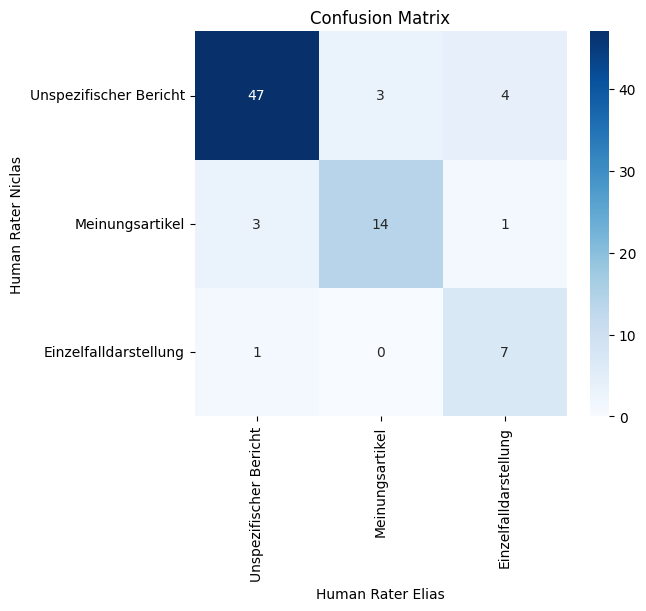

Cohen's Kappa: 0.7041
Matthews Correlation Coefficient: 0.7075


In [28]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score, matthews_corrcoef
from matplotlib import pyplot as plt
import seaborn as sns

def evaluate_rater_agreement(labels_1: pd.Series, name_1: str, labels_2: pd.Series, name_2: str):

    mask = labels_1.notna() & labels_2.notna()
    labels_1 = labels_1[mask]
    labels_2 = labels_2[mask]

    labels = list(set(labels_1) | set(labels_2))

    cm = confusion_matrix(labels_1, labels_2, labels=labels)
    kappa = cohen_kappa_score(labels_1, labels_2, labels=labels)
    mcc = matthews_corrcoef(labels_1, labels_2)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel(name_2)
    plt.ylabel(name_1)
    plt.title('Confusion Matrix')
    plt.show()
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")

evaluate_rater_agreement(niclas_df["label"], "Human Rater Niclas", elias_df["label"], "Human Rater Elias")

In [29]:
# Show disagreemnts
disagreement_df = pd.merge(niclas_df, elias_df["label"], left_index=True, right_index=True, suffixes=("_niclas", "_elias"))
disagreement_df[disagreement_df["label_niclas"] != disagreement_df["label_elias"]]


,url,year,media_title,pseudo_paragraph,label_niclas,label_elias
id,,,,,,
DTT-1955-05-09-a-i0108,https://impresso-project.ch/app/issue/DTT-1955...,1955,Die Tat,Zürichs Lohnverhältnisse sind nicht im gleiche...,Meinungsartikel,Unspezifischer Bericht
FZG-1974-04-27-a-i0062,https://impresso-project.ch/app/issue/FZG-1974...,1974,Freiburger Nachrichten,Der Grund dafür kann nicht in der geringeren A...,Unspezifischer Bericht,Einzelfalldarstellung
NZZ-1880-09-15-a-i0006,https://impresso-project.ch/app/issue/NZZ-1880...,1880,Neue Zürcher Zeitung,Von größter Bedeutung für das zürcherische Arm...,Unspezifischer Bericht,Meinungsartikel
NZZ-1880-10-04-c-i0034,https://impresso-project.ch/app/issue/NZZ-1880...,1880,Neue Zürcher Zeitung,Die hiezu kompetente Behörde ist der Regierung...,Unspezifischer Bericht,Einzelfalldarstellung
NZZ-1881-07-13-b-i0005,https://impresso-project.ch/app/issue/NZZ-1881...,1881,Neue Zürcher Zeitung,Vor zehn Iahren be irgend eine andere protegir...,Meinungsartikel,Unspezifischer Bericht
NZZ-1896-12-21-c-i0001,https://impresso-project.ch/app/issue/NZZ-1896...,1896,Neue Zürcher Zeitung,"nötig gewesen. Im weiteren seien, fo wurde uns...",Meinungsartikel,Einzelfalldarstellung
NZZ-1897-06-09-b-i0001,https://impresso-project.ch/app/issue/NZZ-1897...,1897,Neue Zürcher Zeitung,In der Diskussion redeten Vogelsanger und (Her...,Meinungsartikel,Unspezifischer Bericht
NZZ-1903-12-21-a-i0001,https://impresso-project.ch/app/issue/NZZ-1903...,1903,Neue Zürcher Zeitung,"ging Forster es dabei, wie es wohl vielen Vort...",Unspezifischer Bericht,Meinungsartikel
handelsztg-1875-12-04-a-i0002,https://impresso-project.ch/app/issue/handelsz...,1875,Schweizerische Handels-Zeitung,Apotheker in Bern: dem Bürger-Krankenhaus in T...,Einzelfalldarstellung,Unspezifischer Bericht


## Develop an LLM Labeller

### Split the labelled data

We split the labelled data into two smaller datasets:
- tuning set
- evaluation set

We use the tuning set to repeatedly query the LLM and 'tune' our prompt.
If something gets misclassified with the tuning set, we try to steer the LLM in a better direction.
However, we need to remain general enough in our prompt so that we are not only optimizing for the tuning set, but for all data.

Once we are happy with the results on the tuning set, we evaluate **once** with the evaluation set and don't change the prompt any further!

The resulting metrics give us an impression for how well the model will behave on the whole dataset.

In [38]:
# Create two columns for the LLM responses
labels_df["predicted_label"] = None
labels_df["reasoning"] = None

# Split the dataframe into labelled and unlabelled subsets
unlabelled_df = labels_df[labels_df["label"].isna()].copy() 
gold_df = labels_df[~labels_df["label"].isna()].copy()

In [39]:
from sklearn.model_selection import train_test_split

sample_size = len(gold_df)
evaluation_size = min(20, sample_size // 2)
tuning_size = sample_size - evaluation_size

sample_df = gold_df.sample(sample_size, random_state=42)
evaluation_df, tuning_df = train_test_split(
    sample_df,
    test_size=tuning_size,
    random_state=42,
    stratify=sample_df["label"],
)

print("Evaluation set label distribution:")
print(evaluation_df["label"].value_counts())
print()

print("Tuning set label distribution:")
print(tuning_df["label"].value_counts())

Evaluation set label distribution:
label
Unspezifischer Bericht    14
Meinungsartikel            4
Einzelfalldarstellung      2
Name: count, dtype: int64

Tuning set label distribution:
label
Unspezifischer Bericht    40
Meinungsartikel           14
Einzelfalldarstellung      6
Name: count, dtype: int64


### Define the labels for the LLM

![categories_better](../assets/armenpflege_kategoriensystem.excalidraw.png)

In [19]:
# ⬇️⬇️⬇️ Adjust the categories according to your data
categories = {
    "Meinungsartikel": "The article expresses a subjective opinion or stance or desired actions regarding the 'Armenpflege'. This can be the opinion of the author or of other individuals mentioned in the article. Reports on political discussions are included, if the stances are portrayed. Meinungsartikel may be emotionally charged but can also be very neutral and argumentative.",
    "Einzelfalldarstellung": "The article describes a specific individual case of a person or a group of people that interacted with the 'Armenpflege', predominantly recipients of charity. The mention of singular politicians or speakers or political acts is no Einzelfalldarstellung.",
    "Unspezifischer Bericht": "The article is an objective report that does not fall under the other categories. It is most often about the outcomes of political events, and it is the most common category in the data.",
}
# ⬆️⬆️⬆️

## Few-Shot Prompting

Copy the output of the cell below into the next cell and fill in examples from your data.

In [20]:
obj = {category: "   " for category in categories.keys()}
print("FEW_SHOT_EXAMPLES = " + json.dumps(obj, indent=2))

FEW_SHOT_EXAMPLES = {
  "Meinungsartikel": "   ",
  "Einzelfalldarstellung": "   ",
  "Unspezifischer Bericht": "   "
}


In [21]:
# ⬇️⬇️⬇️ # Copy-paste and fill in here
FEW_SHOT_EXAMPLES = {
  "Meinungsartikel": "Traf und anschaulich der Abschnitt: « Sozialpolitik der Gemeinde », wo es heißt: « Es ist dringend nötig, daß die Beamten mit sozialem Oele gesalbt werden. Sonst knarrt das Räderwerk der Bürokratie in einer unerträglichen Weise. Der Betreibungsbeamte wird die harten Gläubiger gegen den würdigen armen Schuldner zur Milde stimmen... Der Zivilstandsbeamte wird, wenn es nötig und tunlich, die Brautleute zur kirchlichen Trauung bewegen Ein Apostolat von unschätzbarem Werte üben die staatlichen und kommunalen Armenpfleger, zumal durch die Sorge für gute christliche Erziehung der ihnen anvertrauten Kinder. Ebenso die Friedensrichter durch Verhinderung leichtfertiger Prozesse und Schlichtung von Feindschaften. » Hier schreibt Prof. Dr. Beck den Satz, der seine eigene Schriftstellertätigkeit erklärt: « Sei also der Sämann, erfasse das herrliche Saatgut lichtvoller und lebensspendender katholischer Volksschriften und wirf sie mit kräftiger Hand hinein in die Furchen der Zeit und des heutigen Volkslebens!» So wurde denn Prof. Beck, ungeachtet seines Lehrstuhles an der Universität, « der schweizerische Alban Stolz im Volkskalender für Freiburg und Wallis. » Schon im ersten Jahrgang 1910 eröffnete sich Professor Beck hier eine richtige Bauernkanzel.",
  "Einzelfalldarstellung": ". Charles Bilat, durch Strafverfügung der eidgenössischen Oberzolldirektion vom 17, Mai 1948 zu einer Busse von Fr. 406.67 verurteilt, unter Nachlass eines Bussendrittels wegen vorbehaltloser Unterziehung, weil er 2000 Heftchen Zigarettenpapier gekauft und weiterveräussert hatte, obwohl er wusste, dass dasselbe aus Frankreich in die Schweiz eingeschmuggelt worden war, Der Verurteilte ersucht um Brlass der Busse, die er nicht zahlen könne. Er sei Vater von vier minderjährigen Kindern, und sein Einkommen als einfacher Handlanger sei bescheiden. Sollte die Busse in Haft umgewandelt werden, so müsste seine Familie durch die Armenpflege unterstützt werden. Die eidgenössische Oberzolldirektion beantragt, das Gesuch zurzeit abzuweisen. Demgegenüber beantragen wir die Herabsetzung der Busse bis zu Fr. 100, weil Bilat gut beleumdet ist und nachgewiesenermassen in ärmlichen Verhältnissen lebt. Ein weiteres Entgegenkommen können wir indessen nicht befürworten.",
  "Unspezifischer Bericht": "Es werden gewählt: Usteri'Pestlllozzi, Kollbrunner, Dr. Kunz, Zellweger. Dr. Bader, Pflüger, Suter- Thahien, Streuli-tzoen. Präsident: Usteri- P e st a l 0 z z i. Die Armenpflege und die Waisenhauspflege sollen erst neu bestellt werden » ach dem Volksentscheid über die neue Gemeindeordnung. Es werden auch die andern auf der Traktandenliste vorgesehenen Wähle » verschöbe ». Folgenden Bürgerrechtsgesuchen wird ent » sprüche «: Wilhelm Friedr. Bubeck." # NZZ-1907-08-26-a-i0001
}
# ⬆️⬆️⬆️

In [22]:
# This response format forces the model to always return an expected structure
response_format = {
            "type": "json_schema",
            "json_schema": {
                "name": "armenpflege_classification",
                "strict": True,
                "schema": {
            "type": "object",
            "properties": {
                # Reasoning needs to be generated before the label.
                # That way, the model can use its own generated reasoning to determine the label.
                "reasoning": {
                    "type": "string"
                },
                "label": {
                    "type": "string",
                    "enum": list(categories.keys())
                },
            },
            "required": ["label", "reasoning"],
            "additionalProperties": False
        }
    }
}

def get_model_response(post: str) -> dict:
    system_prompt = (

        # ⬇️⬇️⬇️ Adjust the system prompt to guide the model's response
        "You are a classifier for historical articles on 'Armenpflege'. "
        "You are given a text excerpt from a historical news page. "
        "The OCR can be faulty, and the text may contain sentences from other articles at the start and end. "
        "Only classify the thematic cluster around 'Armenpflege' in the middle of the text, not the sentences at the start and end. "
        "Your task is to identify the relevant section of the text and classify the article into one of the following categories based on its content and style. "
        # ⬆️⬆️⬆️
        "\n"

        # Define the output format and instructions for the model
        "You must return a JSON object with the following structure with exactly two fields: "
        "\"reasoning\" (a very VERY brief explanation of why the post was classified with the chosen label as opposed to the other labels), "
        "\"label\" (one of: "
        + ", ".join([f"'{cat}' ({desc})" for cat, desc in categories.items()])
        + "), "
        "Return only the JSON object, nothing else."
        "\n"

        # Add examples for few-shot learning
        "Here are some examples of how to classify articles on 'Armenpflege':\n"
        + "\n\n".join([f"Post: '{example}'\nResponse: {json.dumps({'reasoning': '...', 'label': cat}, indent=2)}" for cat, example in FEW_SHOT_EXAMPLES.items()])
    )
    user_prompt = f"Post: '{post}'"

    with OpenRouter(
      api_key=os.getenv("OPENROUTER_API_KEY"),
    ) as client:
        response = client.chat.send(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=response_format,
            max_tokens=120,
        )

    prediction = json.loads(response.choices[0].message.content)

    return prediction

get_model_response("25 beträgt, wird Kenntnis genommen. An die Kosten der Rodung und Urbarisierung der « Esclhaldc », Gemeinde Muttenz, wird ein Staatsbeitrag bewilligt. Vom vorliegenden Bericht der durchgeführten Gewerbehilfe des Schweizerischen Verbandes der gewerblichen Bürgschaftsgenossenschaften wird Kenntnis genommen. Die Wahlen eines Mitgliedes des Gemeinderates Lausen, eines Mitgliedes der Armenpflege Giebenach und einer Primarlehrcrin für die Gemeinden Arisdorf und Hersberg werden bestätigt. Sanierung des Kirchen- und Schulgutes —st. Seit mehreren Jahren geht das Vermögen des Kirchen- und Schulgutes und damit auch der Zinsertrag unaufhaltsam zurück. Innert zwanzig Jahren hat des Vermögen um 300 911 Fr. abgenommen und betrug 1940 noch 2 986 910 Fr.; an Zinsen stehen 66 572 Fr. weniger zur Verfügung.")

{'reasoning': 'Es geht nur um die Bestätigung einer Wahl in die Armenpflege ohne Fallbeschreibung oder Haltung dazu.',
 'label': 'Unspezifischer Bericht'}

In [23]:
def safe_get_model_response(article: str): 
    """Wrap the get_model_response function in a try-except block to handle potential errors gracefully."""
    try:
        prediction = get_model_response(article)
        label = prediction.get("label", "error")
        reasoning = prediction.get("reasoning", "No reasoning provided.")
        return pd.Series([label, reasoning])
    except Exception as e:
        print(f"Error processing article: {e}")
        return pd.Series(["error", str(e)])

tuning_df[["predicted_label", "reasoning"]] = tuning_df["pseudo_paragraph"].progress_apply(safe_get_model_response)

  0%|          | 0/60 [00:00<?, ?it/s]

Error processing article: Expecting value: line 1 column 1 (char 0)


In [32]:
tuning_df

,url,year,media_title,pseudo_paragraph,label,predicted_label,reasoning
id,,,,,,,
OIZ-1958-03-06-a-i0019,https://impresso-project.ch/app/issue/OIZ-1958...,1958,Die Gewerkschaft,Der verhältnismäßig gute Aufmarsch von unserer...,Unspezifischer Bericht,Meinungsartikel,Es geht um eine Wahl- und Listenempfehlung zur...
NZZ-1931-08-19-a-i0001,https://impresso-project.ch/app/issue/NZZ-1931...,1931,Neue Zürcher Zeitung,Eine davon betrieb Jahrzehnte hiuduich das Hot...,Unspezifischer Bericht,Unspezifischer Bericht,Berichtet sachlich über eine kantonale Kommiss...
FedGazDe-1934-05-23-a-i0003,https://impresso-project.ch/app/issue/FedGazDe...,1934,Bundesblatt,Keller ersucht um Begnadigung. Er habe den Jag...,Einzelfalldarstellung,Einzelfalldarstellung,Im Mittelpunkt steht ein konkreter Bittsteller...
handelsztg-1875-12-04-a-i0002,https://impresso-project.ch/app/issue/handelsz...,1875,Schweizerische Handels-Zeitung,Apotheker in Bern: dem Bürger-Krankenhaus in T...,Einzelfalldarstellung,Unspezifischer Bericht,Es ist eine Aufzählung von Stiftungen und Spen...
obermosel-1898-10-14-a-i0014,https://impresso-project.ch/app/issue/obermose...,1898,Obermosel-Zeitung,trat eine Frau in einen Modewarenladen der rue...,Einzelfalldarstellung,Einzelfalldarstellung,Der Kern ist ein konkreter Fall eines verlasse...
SMZ-1908-02-22-a-i0005,https://impresso-project.ch/app/issue/SMZ-1908...,1908,SMUV-Zeitung,"Die Erfahrungen, die seit Einführung der Haftp...",Meinungsartikel,Unspezifischer Bericht,Der Text argumentiert sachlich für ein Rentens...
DTT-1954-10-27-a-i0067,https://impresso-project.ch/app/issue/DTT-1954...,1954,Die Tat,Regierungspräsident Dr. Meierhans hieß hier di...,Unspezifischer Bericht,Meinungsartikel,Der Abschnitt behandelt eine konkrete kommunal...
FZG-1937-06-05-a-i0015,https://impresso-project.ch/app/issue/FZG-1937...,1937,Freiburger Nachrichten,"Der Frau obliegt es, die erböhte Nische in jed...",Meinungsartikel,Unspezifischer Bericht,Berichtet sachlich über Maßnahmen der Direktio...
NZZ-1881-07-13-b-i0005,https://impresso-project.ch/app/issue/NZZ-1881...,1881,Neue Zürcher Zeitung,Vor zehn Iahren be irgend eine andere protegir...,Meinungsartikel,Meinungsartikel,Deutlich wertend und polemisch zur staatlichen...


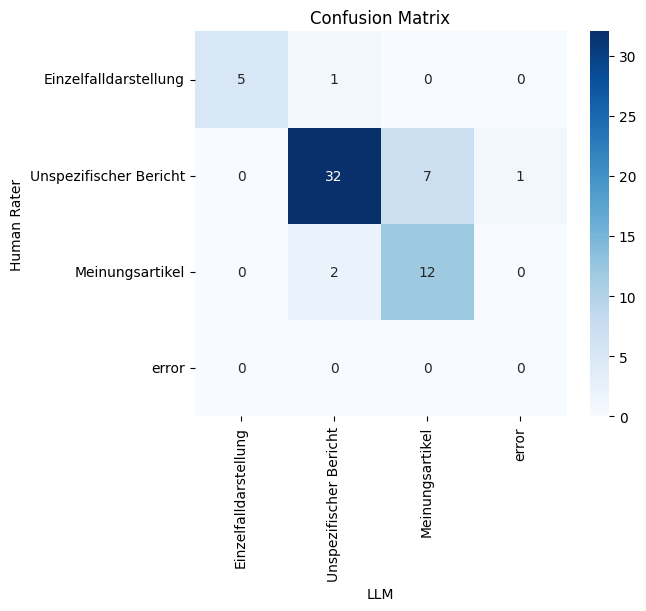

Cohen's Kappa: 0.6534
Matthews Correlation Coefficient: 0.6635


In [33]:
evaluate_rater_agreement(tuning_df["label"], "Human Rater", tuning_df["predicted_label"], "LLM")


#### Inspect disagreements

In [26]:
tuning_df[tuning_df["label"] != tuning_df["predicted_label"]][["pseudo_paragraph", "label", "predicted_label", "reasoning"]]

,pseudo_paragraph,label,predicted_label,reasoning
id,,,,
OIZ-1958-03-06-a-i0019,Der verhältnismäßig gute Aufmarsch von unserer...,Unspezifischer Bericht,Meinungsartikel,Es geht um eine Wahl- und Listenempfehlung zur...
handelsztg-1875-12-04-a-i0002,Apotheker in Bern: dem Bürger-Krankenhaus in T...,Einzelfalldarstellung,Unspezifischer Bericht,Es ist eine Aufzählung von Stiftungen und Spen...
SMZ-1908-02-22-a-i0005,"Die Erfahrungen, die seit Einführung der Haftp...",Meinungsartikel,Unspezifischer Bericht,Der Text argumentiert sachlich für ein Rentens...
DTT-1954-10-27-a-i0067,Regierungspräsident Dr. Meierhans hieß hier di...,Unspezifischer Bericht,Meinungsartikel,Der Abschnitt behandelt eine konkrete kommunal...
FZG-1937-06-05-a-i0015,"Der Frau obliegt es, die erböhte Nische in jed...",Meinungsartikel,Unspezifischer Bericht,Berichtet sachlich über Maßnahmen der Direktio...
NZZ-1874-05-03-a-i0010,"de » ach deren Steueransatz zu 2,4 arniensteue...",Unspezifischer Bericht,Meinungsartikel,Der Text diskutiert allgemein die Armensteuer-...
luxwort-1942-04-21-a-i0049,Nicht Armenpflege sondern Volkswohlfahrt Hilfs...,Unspezifischer Bericht,Meinungsartikel,Klare wertende Gegenüberstellung von alter Arm...
NZZ-1880-09-15-a-i0006,Von größter Bedeutung für das zürcherische Arm...,Unspezifischer Bericht,error,Expecting value: line 1 column 1 (char 0)
luxwort-1941-09-15-a-i0024,Fürsorge ist die Sorge für das wirtschaftliche...,Unspezifischer Bericht,Meinungsartikel,"Der Text ist grundsätzliche, normativ-argument..."


In [34]:
def show_single_inference(df: pd.DataFrame, id: str):
    row = df.loc[id]

    print(f"ID:                  {id}")
    print(f"Human Label:         {row['label']}")
    print(f"LLM Predicted Label: {row['predicted_label']}", end="\n\n")
    print(f"Reasoning:")
    print(textwrap.fill(row['reasoning'], width=80), end="\n\n")
    print(f"Article Pseudo-Paragraph:")
    print(textwrap.fill(row['pseudo_paragraph'], width=80))

# ⬇️⬇️⬇️ Adjust the ID to show the inference for a specific article
show_single_inference(tuning_df, "DTT-1962-03-02-a-i0143")
# ⬆️⬆️⬆️

ID:                  DTT-1962-03-02-a-i0143
Human Label:         Unspezifischer Bericht
LLM Predicted Label: Unspezifischer Bericht

Reasoning:
Der Abschnitt ist eine sachliche Würdigung eines Amtsinhabers und der Belastung
des Fürsorgeamts, ohne Einzelfall oder klare Meinungsführung zur Armenpflege.

Article Pseudo-Paragraph:
Zudem wurde auch die Loslösung vom Finanzausgleich vollzogen. Vielfältige neue
Aufgaben müssen bald finanziell sichergestellt werden. Ernst Truttmann verfügt
als Sub-Direk tor einer grossen schweizerischen Bank über die notwendige
Qualifikation zu diesem Amt. Otto Zeier ( 4) Als Vorsteher des Fürsorgeamtes,
als Mitglied der Armenpflege und als Präsident des Mietamtes ist Bankprokurist
Otto Zeier ein verständnisvoller Berater aller Ratsuchender. Das ständige
Wachstum unserer Gemeinde bedingt eine zunehmende Beanspruchung des
Fürsorgeamtes. So hat sich das Arbeitspensum im Laufe der letzten Jahre derart
erweitert, dass dasselbe mit Recht als eines der meistbclastet

#### 🔄️ Repeat

Now you have determined how the model behaves on the tuning set given your prompt.
You can now rework your prompt, and optimize on the tuning set until you are happy with the results.

⚠️ **But take caution!** If your prompt is too heavily tailored to the tuning set, it will no longer generalize to the whole data!

To test this generalization, we finally evaluate the prompt on the evaluation set.
The results give us an impression on how well the model will behave on unseen data.
*But only if we don't change it anymore after seeing the results on the evaluation set!*

In [35]:
evaluation_df[["predicted_label", "reasoning"]] = evaluation_df["pseudo_paragraph"].progress_apply(safe_get_model_response)

  0%|          | 0/20 [00:00<?, ?it/s]

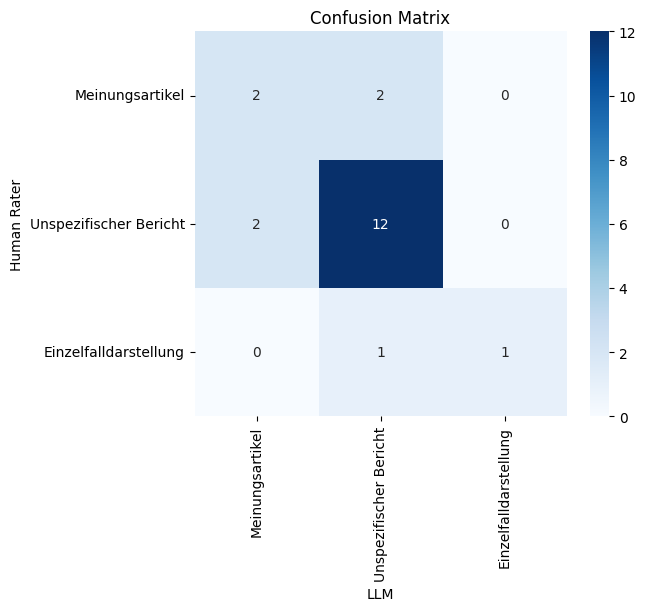

Cohen's Kappa: 0.4186
Matthews Correlation Coefficient: 0.4223


In [36]:
evaluate_rater_agreement(evaluation_df["label"], "Human Rater", evaluation_df["predicted_label"], "LLM")

In [39]:
print("Accuracy:", (evaluation_df["label"] == evaluation_df["predicted_label"]).mean())

Accuracy: 0.75


## Run inference on full unlabelled set

### Add already inferred labels to the output

We already inferred labels for the articles in the tuning_df and evaluation_df.
Therefore, we add these labels to the final output.

In [40]:
if LOAD_OWN_DATA:
    INFERENCE_OUTPATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.llm.csv"
    if INFERENCE_OUTPATH.exists():
        inference_df = pd.read_csv(INFERENCE_OUTPATH, index_col="id", sep=",")
    else:
        inference_df = pd.DataFrame(columns=["predicted_label", "reasoning"])
    
    predicted_tuning_df = tuning_df[tuning_df["predicted_label"].notna()]
    predicted_tuning_df = predicted_tuning_df[["predicted_label", "reasoning"]]

    predicted_evaluation_df = evaluation_df[evaluation_df["predicted_label"].notna()]
    predicted_evaluation_df = predicted_evaluation_df[["predicted_label", "reasoning"]]

    inference_df = pd.concat([inference_df, predicted_tuning_df, predicted_evaluation_df], axis=0)
    inference_df = inference_df[~inference_df.index.duplicated(keep="first")]
    inference_df.to_csv(INFERENCE_OUTPATH, index=True)

### Determine the articles still missing a predicted label

In [42]:
if LOAD_OWN_DATA:
    TIMEOUT = 0  # The response will take long enough, so we can set timeout to 0 to avoid unnecessary waiting time between requests

    def load_missing_inference_ids(print_info: bool = True) -> tuple[list[str], pd.DataFrame]:
        """Load the list of unlabeled items and check which ones still need inference."""
        # if INFERENCE_OUTPATH.exists():
        #     inference_df = pd.read_csv(INFERENCE_OUTPATH, index_col="id")
        # else:
        #     inference_df = pd.DataFrame(columns=["predicted_label", "reasoning"])
        inference_df = pd.read_csv(INFERENCE_OUTPATH, index_col="id")
        already_inferred_ids = set(inference_df.index.to_list())

        # Get IDs that need inference
        missing_ids = [id for id in labels_df.index if id not in already_inferred_ids]
        
        if print_info:
            print(f"Missing {len(missing_ids)} items. (Already inferred {len(already_inferred_ids)})")
            print(f"Requests for missing items will take approximately {len(missing_ids) * max(TIMEOUT, 1) / 60:.2f} minutes (assuming ~{1 / max(TIMEOUT, 1):.2f} request per second).")
        
        return missing_ids, inference_df

    missing_ids, inference_df = load_missing_inference_ids()
    
else:
    print("Skipping loading of existing inference results since LOAD_OWN_DATA is set to False.")

Missing 0 items. (Already inferred 2602)
Requests for missing items will take approximately 0.00 minutes (assuming ~1.00 request per second).


In [41]:
confirm("Do you want to run inference on the full unlabelled set? This will make API calls for each unlabelled item and may take a long time. Do you want to proceed?")  

# Reload missing IDs to ensure we have the latest state
missing_ids, inference_df = load_missing_inference_ids()

try:
    for i, doc_id in enumerate(missing_ids):
        time.sleep(random.uniform(TIMEOUT * 0.5, TIMEOUT * 1.5))
        print(f"({i+1}/{len(missing_ids)}) - Processing document {doc_id}", end="\r")
        
        # Get the text from unlabelled_df
        article_text = unlabelled_df.loc[doc_id, "pseudo_paragraph"]
        
        # Run inference
        prediction = safe_get_model_response(article_text)
        
        # Create a row with the prediction
        row_df = pd.DataFrame({
            "id": [doc_id],
            "predicted_label": [prediction[0]],
            "reasoning": [prediction[1]]
        }).set_index("id")
        
        inference_df = pd.concat([inference_df, row_df], ignore_index=False)
        
        if (i + 1) % 100 == 0:  # Save progress every 100 items
            inference_df.to_csv(INFERENCE_OUTPATH, index=True)
            print(f"Progress saved: {i+1}/{len(missing_ids)} items processed       ")

except KeyboardInterrupt:
    print(f"\nProcess interrupted by user. Saving progress...                              ")
    inference_df.to_csv(INFERENCE_OUTPATH, index=True)
    raise KeyboardInterrupt("Inference process interrupted by user. Progress saved.")
except Exception as e:
    print(f"\nAn error occurred. Saving progress...                              ")
    inference_df.to_csv(INFERENCE_OUTPATH, index=True)
    raise e

# Final save
inference_df.to_csv(INFERENCE_OUTPATH, index=True)
print(f"Inference complete! Results saved to {INFERENCE_OUTPATH}")

Missing 2430 items. (Already inferred 92)
Requests for missing items will take approximately 40.50 minutes (assuming ~1.00 request per second).
Progress saved: 100/2430 items processed       5-02-19-a-i0013
Error processing article: Expecting value: line 1 column 1 (char 0)
Progress saved: 200/2430 items processed       03-27-a-i0004000718
Error processing article: Response validation failed: 6 validation errors for Unmarshaller
body.choices
  Field required [type=missing, input_value={'error': {'message': 'Th... email.)', 'code': 502}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
body.created
  Field required [type=missing, input_value={'error': {'message': 'Th... email.)', 'code': 502}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
body.id
  Field required [type=missing, input_value={'error': {'message': 'Th... email.)', 'code': 502}}, input_type=dict]
    For further information visit 

### Inspect inference results

In [67]:
INFERENCE_OUTPATH = DATA_DIR / f"{CORPUS_NAME}.filtered.pp.label.llm.csv"
full_inference_df = pd.read_csv(INFERENCE_OUTPATH, index_col="id")

In [53]:
print(f"Total inferred items: {len(full_inference_df)}")
print("\nLabel distribution:")
print(full_inference_df["predicted_label"].value_counts())
print(f"\nResults saved to: {INFERENCE_OUTPATH}")

Total inferred items: 2602

Label distribution:
predicted_label
Unspezifischer Bericht    1372
Meinungsartikel            970
Einzelfalldarstellung      240
error                       20
Name: count, dtype: int64

Results saved to: ../data/armenpflege.filtered.pp.label.llm.csv


#### Show label distribution across time

In [68]:
full_inference_df = full_inference_df.join(labels_df[["year"]], how="left")
full_inference_df = full_inference_df[full_inference_df["predicted_label"] != "error"]

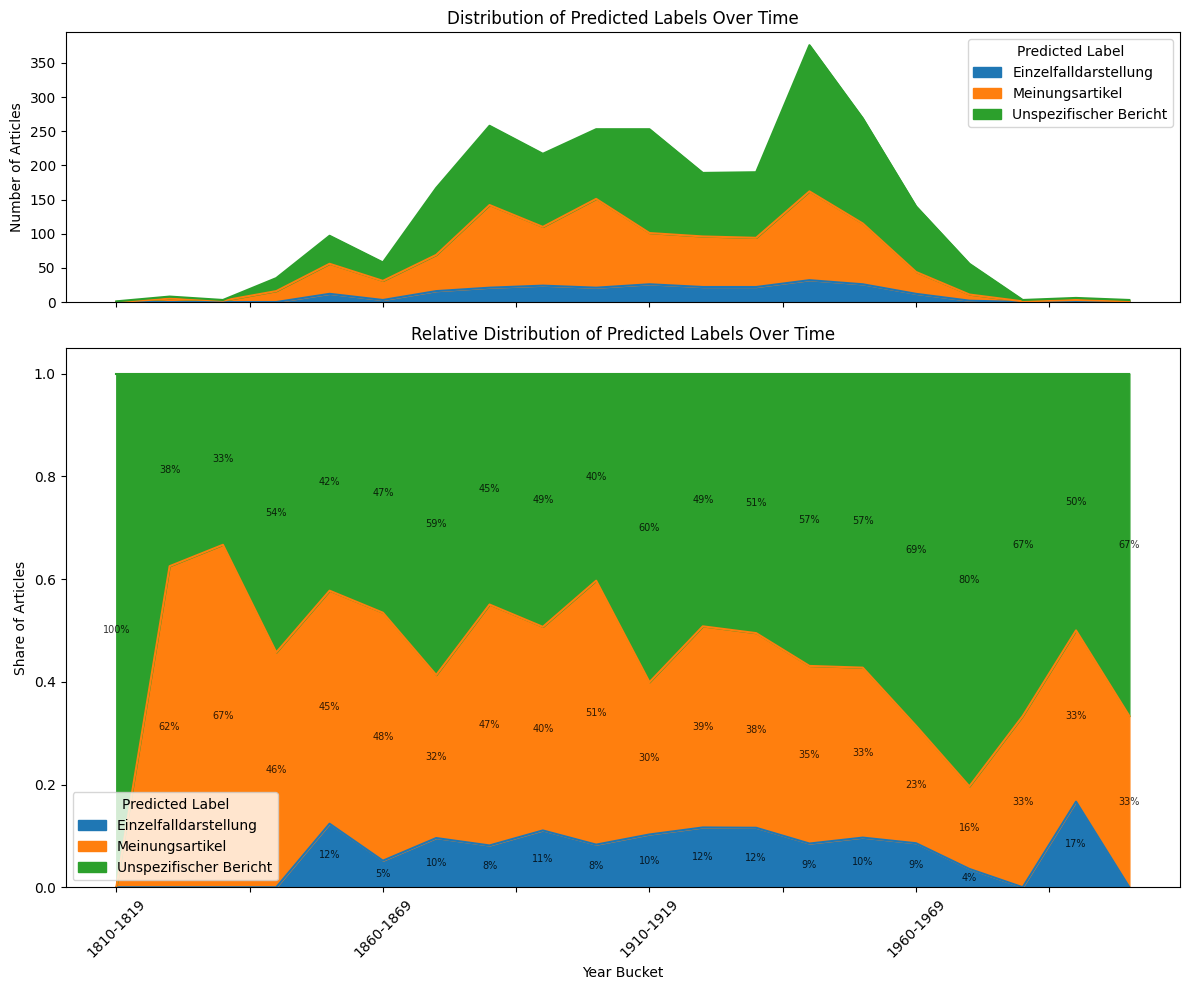

In [78]:
import matplotlib.pyplot as plt

def plot_predicted_labels_over_time(df: pd.DataFrame, bucket_size: int):
    df = df.copy()
    df = df[df["year"].notna()].copy()
    df["year"] = df["year"].astype(int)

    start = (df["year"].min() // bucket_size) * bucket_size
    end = (df["year"].max() // bucket_size + 1) * bucket_size

    # Include the final bin edge so the newest interval is not dropped.
    bins = range(start, end + 1, bucket_size)
    labels = [f"{bucket_start}-{bucket_start + bucket_size - 1}" for bucket_start in bins[:-1]]
    df["year_bucket"] = pd.cut(
        df["year"],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )

    label_counts_by_bucket = df.groupby(["year_bucket", "predicted_label"], observed=False).size().unstack(fill_value=0)
    label_counts_by_bucket = label_counts_by_bucket.reindex(labels, fill_value=0)
    label_counts_by_bucket_percentage = label_counts_by_bucket.div(
        label_counts_by_bucket.sum(axis=1).replace(0, pd.NA),
        axis=0,
    ).fillna(0)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 10),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 2]},
    )

    label_counts_by_bucket.plot(kind="area", stacked=True, ax=axes[0])
    axes[0].set_title("Distribution of Predicted Labels Over Time")
    axes[0].set_xlabel("Year Bucket")
    axes[0].set_ylabel("Number of Articles")
    axes[0].legend(title="Predicted Label")

    label_counts_by_bucket_percentage.plot(kind="area", stacked=True, ax=axes[1])
    axes[1].set_title("Relative Distribution of Predicted Labels Over Time")
    axes[1].set_xlabel("Year Bucket")
    axes[1].set_ylabel("Share of Articles")
    axes[1].legend(title="Predicted Label")

    # Add small percentage annotations inside each stacked area segment.
    frac_values = label_counts_by_bucket_percentage
    for x_pos in range(len(frac_values.index)):
        lower = 0.0
        for col in frac_values.columns:
            value_frac = float(frac_values.iloc[x_pos][col])
            if value_frac <= 0:
                continue
            y_pos = lower + value_frac / 2
            if value_frac >= 0.03:
                axes[1].text(
                    x_pos,
                    y_pos,
                    f"{int(round(value_frac * 100))}%",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="black",
                    alpha=0.8,
                )
            lower += value_frac

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

# Create stacked area charts for absolute and relative label distribution over time.

# ⬇️⬇️⬇️
BUCKET_SIZE = 10  # Adjust the bucket size and critique its effect on the visualization.

plot_predicted_labels_over_time(full_inference_df, bucket_size=BUCKET_SIZE)